In [1]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
class datasets():
    def __init__(self, transforms, df):
        self.t = transforms
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        img = row["image_add"]
        img = self.t(Image.open(img).convert("RGB"))
        lab = row["Class"]
        lab = torch.tensor(lab, dtype=torch.int64)
        return img, lab


In [3]:
train_dataset_32 = torch.load("Transformed_Data/train_dataset_32.pt", weights_only=False)
train_dataset_256 = torch.load("Transformed_Data/train_dataset_256.pt", weights_only=False)


In [4]:
img, lab = next(iter(train_dataset_32))
img.shape, lab


(torch.Size([3, 32, 32]), tensor(0))

In [5]:
img1, lab1 = next(iter(train_dataset_256))
img1.shape, lab1


(torch.Size([3, 256, 256]), tensor(0))

In [6]:
np.array(img1).shape


C:\Users\divyadarshee dash\AppData\Local\Temp\ipykernel_14508\697792856.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(img1).shape


(3, 256, 256)

In [7]:
np.array(img1)[0][1]


C:\Users\divyadarshee dash\AppData\Local\Temp\ipykernel_14508\1967721147.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(img1)[0][1]


array([-0.12785512, -0.12785512, -0.11118888, -0.11118888, -0.11118888,
       -0.09452263, -0.09452263, -0.07785638, -0.06119013, -0.04452388,
       -0.04452388, -0.02785764, -0.02785764, -0.02785764, -0.02785764,
       -0.02785764, -0.02785764, -0.04452388, -0.04452388, -0.06119013,
       -0.06119013, -0.07785638, -0.09452263, -0.11118888, -0.11118888,
       -0.12785512, -0.14452137, -0.16118762, -0.16118762, -0.17785387,
       -0.17785387, -0.17785387, -0.19452012, -0.19452012, -0.19452012,
       -0.19452012, -0.19452012, -0.19452012, -0.17785387, -0.17785387,
       -0.16118762, -0.16118762, -0.14452137, -0.14452137, -0.14452137,
       -0.14452137, -0.14452137, -0.14452137, -0.16118762, -0.16118762,
       -0.16118762, -0.17785387, -0.17785387, -0.19452012, -0.21118636,
       -0.22785261, -0.24451886, -0.2611851 , -0.2611851 , -0.27785137,
       -0.27785137, -0.27785137, -0.2611851 , -0.2611851 , -0.24451886,
       -0.22785261, -0.22785261, -0.21118636, -0.21118636, -0.21

## trying salt and pepper noise


In [8]:
class salt_and_pepper():
    def __init__(self, s_ratio, noise_perct):
        self.s = s_ratio
        self.n = noise_perct / 100

    def __call__(self, img):
        output = torch.clone(img)
        num_salt = int(self.s * img.shape[1] * img.shape[2] * self.n)
        coord = []
        for i in range(num_salt):
            a = np.random.randint(0, img.shape[2], 1)
            b = np.random.randint(0, img.shape[1], 1)
            coord.append([a[0], b[0]])
        for i in range(len(coord)):
            for j in range(3):
                output[j, coord[i][1], coord[i][0]] = 1

        num_pepper = int((1 - self.s) * img.shape[1] * img.shape[2] * self.n)
        coord = []
        for i in range(num_pepper):
            a = np.random.randint(0, img.shape[2], 1)
            b = np.random.randint(0, img.shape[1], 1)
            coord.append([a[0], b[0]])
        for i in range(len(coord)):
            for j in range(3):
                output[j, coord[i][1], coord[i][0]] = 0

        return output


In [9]:
type(img1)


torch.Tensor

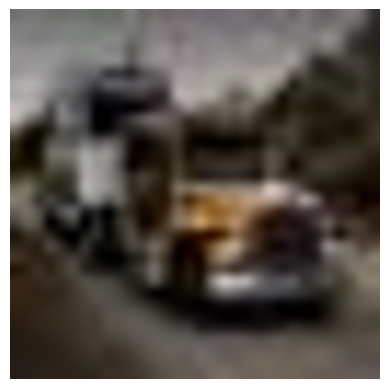

In [10]:
# De-normalize tensor before displaying with matplotlib
def denormalize(tensor, mean=(0.4693, 0.4595, 0.4128), std=(0.2353, 0.2363, 0.2653)):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

plt.imshow(denormalize(img1).permute(1, 2, 0))
plt.axis("off")
plt.show()


In [11]:
img1_sp = salt_and_pepper(0.5, 4)
op = img1_sp(img1)
op


tensor([[[-0.1445, -0.1445, -0.1279,  ..., -1.1445, -1.1612, -1.1778],
         [-0.1279, -0.1279, -0.1112,  ..., -1.1445, -1.1612, -1.1778],
         [-0.1279, -0.1279, -0.1112,  ..., -1.1445, -1.1612, -1.1945],
         ...,
         [-1.4112, -1.4112, -1.4112,  ..., -0.3445, -0.3445, -0.3445],
         [-1.4112, -1.4112, -1.4112,  ..., -0.3445, -0.3445, -0.3445],
         [-1.4112, -1.4112, -1.4112,  ..., -0.3445, -0.3445, -0.3445]],

        [[-0.1356, -0.1356, -0.1190,  ..., -1.1646, -1.1812, -1.1978],
         [-0.1190, -0.1190, -0.1024,  ..., -1.1646, -1.1812, -1.1978],
         [-0.1190, -0.1190, -0.1024,  ..., -1.1646, -1.1812, -1.2144],
         ...,
         [-1.4467, -1.4467, -1.4467,  ..., -0.4344, -0.4344, -0.4344],
         [-1.4467, -1.4467, -1.4467,  ..., -0.4344, -0.4344, -0.4344],
         [-1.4467, -1.4467, -1.4467,  ..., -0.4344, -0.4344, -0.4344]],

        [[ 0.0700,  0.0700,  0.0848,  ..., -0.8760, -0.8908, -0.9056],
         [ 0.0848,  0.0848,  0.0996,  ..., -0

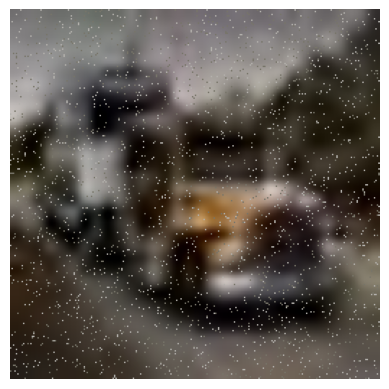

In [12]:
plt.imshow(denormalize(op).permute(1, 2, 0))
plt.axis("off")
plt.show()


In [13]:
def sp_dev(ratio, perc_noise, img):
    mn = salt_and_pepper(ratio, perc_noise)
    img_noisy = mn(img)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(denormalize(img).permute(1, 2, 0))
    plt.title("Before noise")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(denormalize(img_noisy).permute(1, 2, 0))
    plt.title("After noise")
    plt.axis("off")

    plt.show()


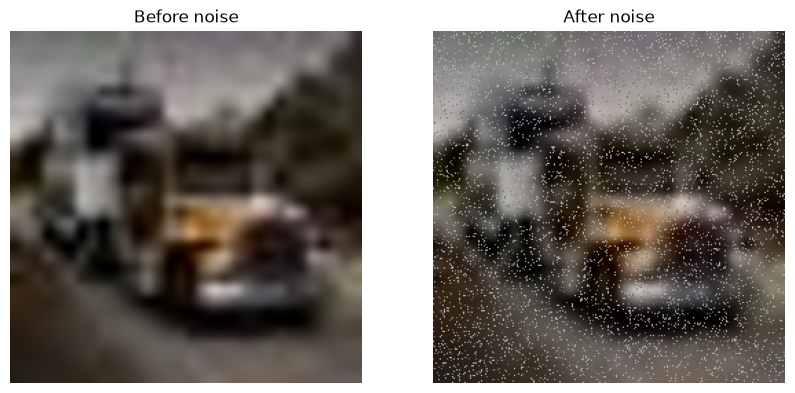

In [20]:
sp_dev(0.6, 10, img1)

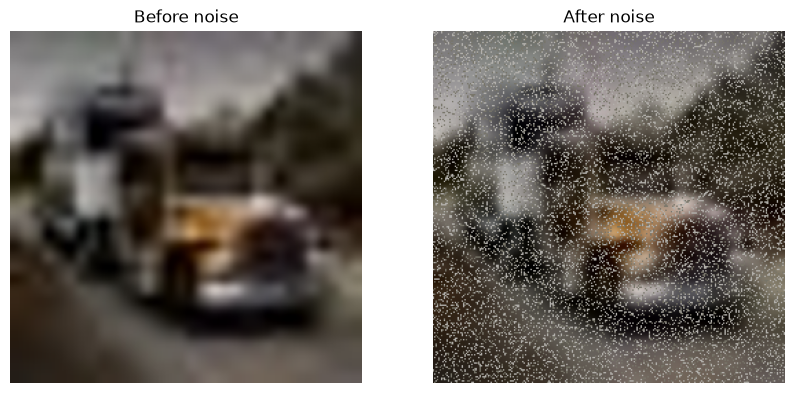

In [14]:
sp_dev(0.6, 25, img1)

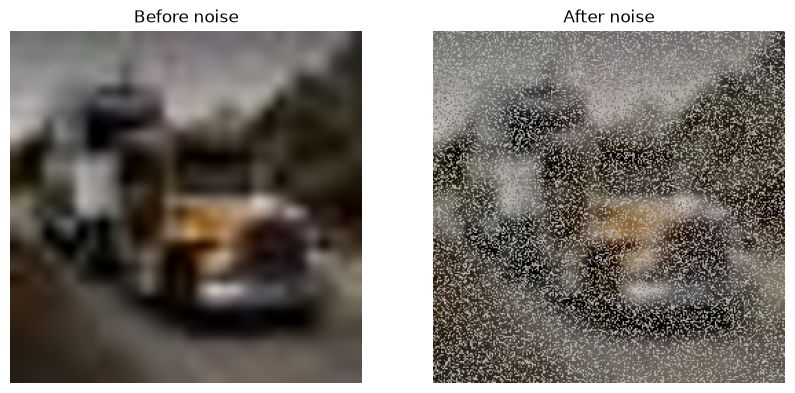

In [15]:
sp_dev(0.6, 50, img1)


<class 'torch.Tensor'>


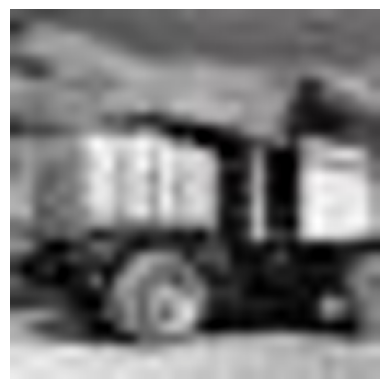

In [16]:
k = train_dataset_256[100]
print(type(k[0]))
plt.imshow(denormalize(k[0]).permute(1, 2, 0))
plt.axis("off")
plt.show()


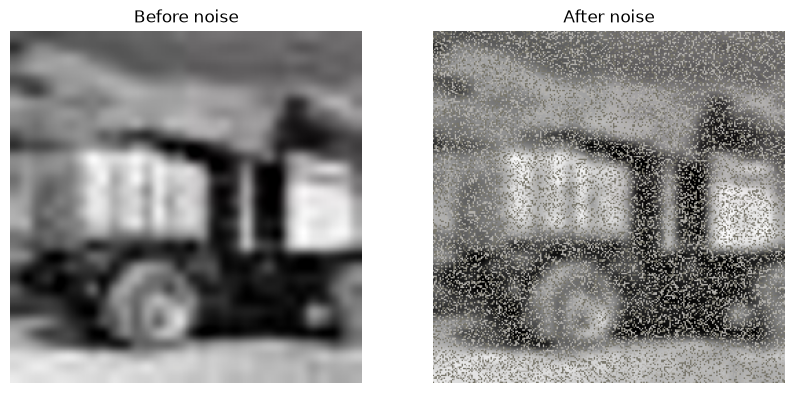

In [17]:
sp_dev(0.6, 50, k[0])

In [21]:
len(train_dataset_256)

100000

In [22]:
import copy

In [26]:
train_copy_sp_256 = copy.deepcopy(train_dataset_256)
len(train_dataset_256)

100000

In [25]:
salt_pepper_dilute = 0.30

In [27]:
num_salt_pepper_dilute = int(len(train_dataset_256) * salt_pepper_dilute )
num_salt_pepper_dilute

30000

In [28]:
cood = np.random.randint(0 , len(train_dataset_256) , 30000)
len(cood)

30000

In [31]:
np.unique(cood)

array([    5,     6,    11, ..., 99988, 99996, 99998],
      shape=(25923,), dtype=int32)

In [33]:
cood = list(set(cood))

In [32]:
img , lab = next(iter(train_copy_sp_256))
img.shape

torch.Size([3, 256, 256])

In [34]:
len(cood)

25923

In [35]:
convert = salt_and_pepper(0.6, 10)

In [ ]:
modified = []

for i in cood:
    img, lab = train_copy_sp_256[i]
    modified.append((convert(img), lab))

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class TinyVGG(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
tvgg_1 = TinyVGG(2)

In [ ]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dev

In [ ]:
tvgg_1.to(device)

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_256 = DataLoader( train_copy_sp_256, batch_size = 32, shuffle = True )

In [ ]:
import torch.optim as optim

In [ ]:
optimizer = optim.Adam(tvgg_1.parameters , lr = 0.0001 )

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
from torchmetrics.classification import Accuracy, F1Score, Precision, Recall

In [ ]:
accuracy = Accuracy(task = "binary")
f1 = F1Score(task = "binary")
precision = Precision(task = "binary")
recall = Recall(task = "binary")

In [ ]:
def train_data(model, dataloader, dev, optimizer, loss_fn,accuracy, f1, precision, recall, epoch):
    model = model.to(dev)
    model.train()
    running_loss = 0.0
    accuracy.reset()
    f1.reset()
    precision.reset()
    recall.reset()

    for images, labels in dataloader:

        images = images.to(dev)
        labels = labels.to(dev).float()

        # Forward
        logits = model(images).squeeze(1)

        # Loss
        loss_value = loss_fn(logits, labels)

        # Backward
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()

        running_loss += loss_value.item()

        # Metrics
        probs = torch.sigmoid(logits)

        accuracy.update(probs, labels.int())
        f1.update(probs, labels.int())
        precision.update(probs, labels.int())
        recall.update(probs, labels.int())

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = accuracy.compute().item()
    epoch_f1 = f1.compute().item()
    epoch_precision = precision.compute().item()
    epoch_recall = recall.compute().item()

    print(
        f"Epoch {epoch} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f} | "
        f"F1: {epoch_f1:.4f} | "
        f"Precision: {epoch_precision:.4f} | "
        f"Recall: {epoch_recall:.4f}"
    )

    return epoch_loss, epoch_accuracy, epoch_f1, epoch_precision, epoch_recall


In [ ]:
def test_data(model, dataloader, dev, loss_fn,
              accuracy, f1, precision, recall):

    model = model.to(dev)
    model.eval()

    running_loss = 0.0

    accuracy.reset()
    f1.reset()
    precision.reset()
    recall.reset()

    with torch.inference_mode():

        for images, labels in dataloader:

            images = images.to(dev)
            labels = labels.to(dev).float()

            # Forward
            logits = model(images).squeeze(1)

            # Loss
            loss_value = loss_fn(logits, labels)

            running_loss += loss_value.item()

            # Metrics
            probs = torch.sigmoid(logits)

            accuracy.update(probs, labels.int())
            f1.update(probs, labels.int())
            precision.update(probs, labels.int())
            recall.update(probs, labels.int())

    test_loss = running_loss / len(dataloader)

    test_accuracy = accuracy.compute().item()
    test_f1 = f1.compute().item()
    test_precision = precision.compute().item()
    test_recall = recall.compute().item()

    print(
        f"Test | "
        f"Loss: {test_loss:.4f} | "
        f"Accuracy: {test_accuracy:.4f} | "
        f"F1: {test_f1:.4f} | "
        f"Precision: {test_precision:.4f} | "
        f"Recall: {test_recall:.4f}"
    )

    return test_loss, test_accuracy, test_f1, test_precision, test_recall

## for size 256

In [ ]:
epoch_loss, epoch_accuracy, epoch_f1, epoch_precision, epoch_recall = (model, dataloader, dev, optimizer,
                                                                       loss_fn,accuracy, f1, precision, recall, epoch)

## for size 32